In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import QuantileTransformer
from sklearn.preprocessing import PowerTransformer

# Загрузка данных

In [43]:
%%capture
!wget https://www.dropbox.com/s/64ol9q9ssggz6f1/data_ford_price.xlsx

In [44]:
data = pd.read_excel(r'C:\Users\user\Desktop\Skilfactory\data1\data_ford_price.xlsx') 

# Трансформация признаков

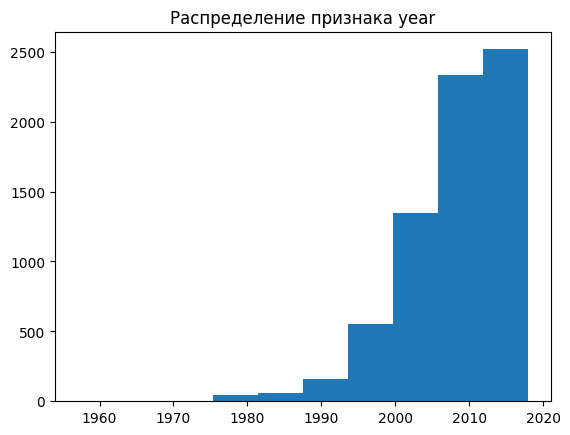

In [45]:
plt.hist(data.year)
plt.title('Распределение признака year');

## Квантильное преобразование

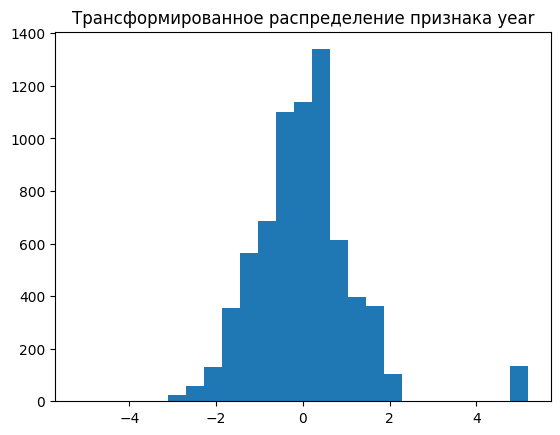

In [46]:
data_for_transform = data['year'].values.reshape((len(data),1))
 
quantile = QuantileTransformer(output_distribution='normal')
data_transformed = quantile.fit_transform(data_for_transform)
 
plt.hist(data_transformed, bins=25)
plt.title('Трансформированное распределение признака year')
plt.show()

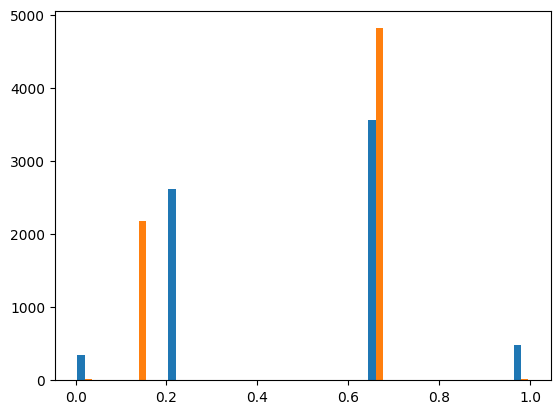

In [47]:
data_for_transform = data[['condition', 'cylinders']]
quantile = QuantileTransformer()
data_transformed = quantile.fit_transform(data_for_transform)
plt.hist(data_transformed, bins=25)
plt.show()

In [48]:
data_transformed

array([[0.96396396, 0.15715716],
       [0.23573574, 0.65515516],
       [0.23573574, 0.65515516],
       ...,
       [0.67617618, 0.65515516],
       [0.23573574, 0.65515516],
       [0.23573574, 0.65515516]])

## Логарифмическое преобразование

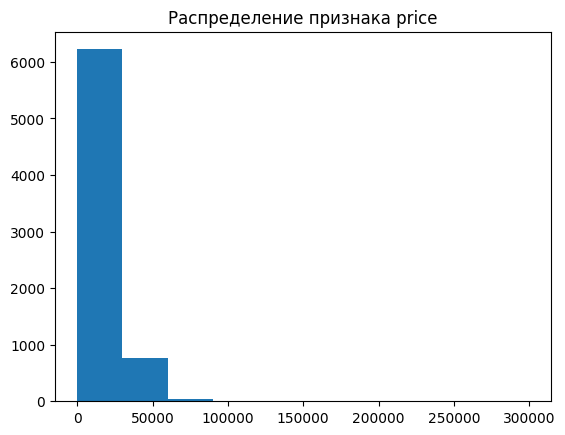

In [49]:
plt.hist(data.price)
plt.title('Распределение признака price');

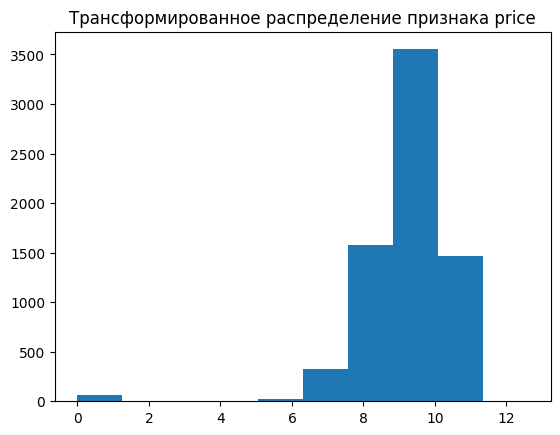

In [50]:
log_price = np.log(data['price'])
 
plt.hist(log_price)
plt.title('Трансформированное распределение признака price')
plt.show()

In [51]:
price_data = pd.concat([data['price'], log_price.rename('transformed_price')], axis = 1)
 
price_data.describe()

,price,transformed_price
count,7017.000000,7017.000000
mean,15121.549523,9.204510
std,11765.423119,1.275868
min,1.000000,0.000000
25%,5995.000000,8.698681
50%,12750.000000,9.453287
75%,21995.000000,9.998570
max,299500.000000,12.609870


In [52]:
price_data['transformed_price']

0       10.689670
1        9.647950
2        7.822044
3        7.170120
4        9.537123
          ...    
7012    10.021271
7013     8.695339
7014     9.210240
7015     9.296518
7016     9.798127
Name: transformed_price, Length: 7017, dtype: float64

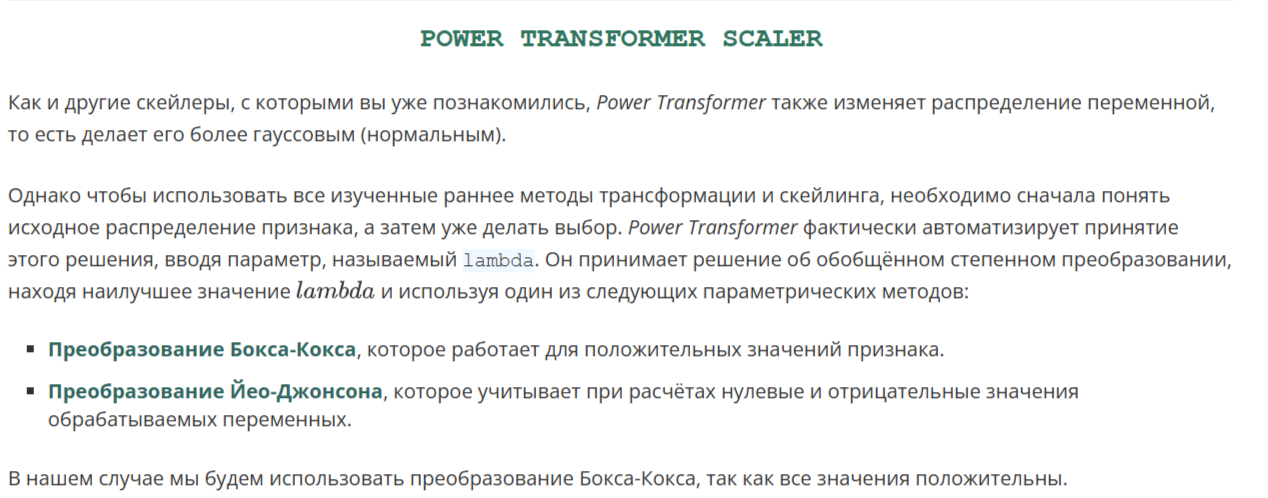

## Преобразование Бокса-Кокса

In [59]:
data = pd.read_excel(r'C:\Users\user\Desktop\Skilfactory\data1\data_ford_price.xlsx')

In [64]:
import pandas as pd
from sklearn.preprocessing import PowerTransformer

# Предположим, что data — это DataFrame с колонками 'price' и 'year'
# Проверим наличие и корректность данных
if 'price' not in data.columns or 'year' not in data.columns:
    raise ValueError("В DataFrame отсутствуют колонки 'price' и 'year'")

# Проверим, есть ли отрицательные значения или нули
if (data[['price', 'year']] <= 0).any().any():
    raise ValueError("Для применения Box-Cox все значения должны быть положительными")

# Преобразование с помощью PowerTransformer
box_cox = PowerTransformer(method='box-cox')

# Создадим копию ДФ для проеобразования boxcox scipy
test_data_year = data.copy()

from scipy.stats import boxcox

data_box_cox_price = box_cox.fit_transform(data[['price']].values)

data_box_cox_year,  = boxcox(test_data_year['year'])

# Создадим DataFrame с преобразованными данными
data_box_cox_price = pd.DataFrame(data_box_cox_price, columns=['transformed_price'])
data_box_cox_year = pd.DataFrame(data_box_cox_year, columns=['transformed_year'])

data_box_cox = pd.concat([data_box_cox_price, data_box_cox_year], axis=1)

c:\Users\user\anaconda3\Lib\site-packages\scipy\stats\_morestats.py:1186: UserWarning: The optimal lambda is 123.77781881071438, but the returned lambda is the constrained optimum to ensure that the maximum or the minimum of the transformed data does not overflow in <class 'numpy.float64'>.
  lmax = boxcox_normmax(x, method='mle', optimizer=optimizer)


ValueError: too many values to unpack (expected 1)

In [57]:
box_cox = PowerTransformer(method = 'box-cox')
 
data_box_cox = box_cox.fit_transform(data[['price', 'year']].values)
data_box_cox = pd.DataFrame(data_box_cox, columns = ['transformed_price', 'transformed_year'])

c:\Users\user\anaconda3\Lib\site-packages\scipy\stats\_morestats.py:1186: UserWarning: The optimal lambda is 123.77781881071438, but the returned lambda is the constrained optimum to ensure that the maximum or the minimum of the transformed data does not overflow in float64.
  lmax = boxcox_normmax(x, method='mle', optimizer=optimizer)
c:\Users\user\anaconda3\Lib\site-packages\sklearn\utils\extmath.py:1163: RuntimeWarning: overflow encountered in square
  temp **= 2
c:\Users\user\anaconda3\Lib\site-packages\sklearn\utils\extmath.py:1169: RuntimeWarning: overflow encountered in square
  new_unnormalized_variance -= correction**2 / new_sample_count
c:\Users\user\anaconda3\Lib\site-packages\sklearn\utils\extmath.py:1169: RuntimeWarning: invalid value encountered in subtract
  new_unnormalized_variance -= correction**2 / new_sample_count
c:\Users\user\anaconda3\Lib\site-packages\sklearn\preprocessing\_data.py:88: RuntimeWarning: overflow encountered in square
  upper_bound = n_samples * ep

c:\Users\user\anaconda3\Lib\site-packages\matplotlib\axes\_axes.py:7104: RuntimeWarning: All-NaN slice encountered
  xmin = min(xmin, np.nanmin(xi))
c:\Users\user\anaconda3\Lib\site-packages\matplotlib\axes\_axes.py:7105: RuntimeWarning: All-NaN slice encountered
  xmax = max(xmax, np.nanmax(xi))


ValueError: autodetected range of [nan, nan] is not finite

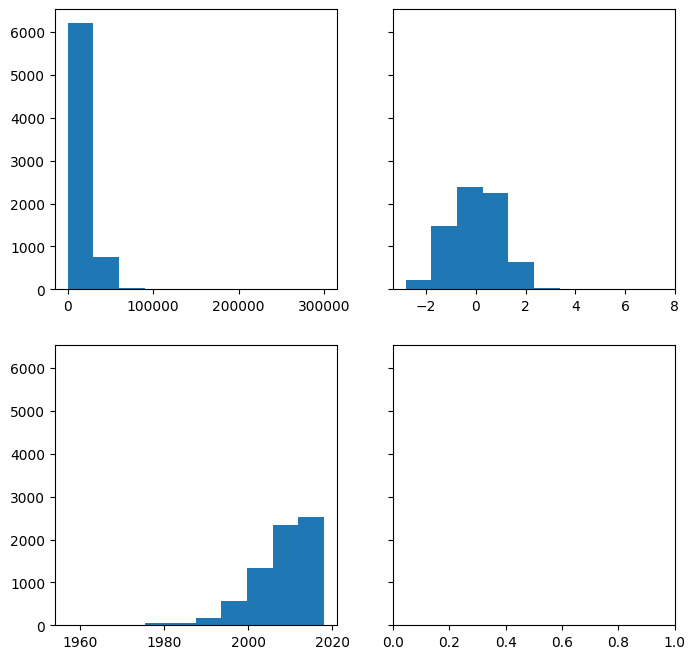

In [58]:
fig, axs = plt.subplots(2, 2, figsize=(8, 8), sharey=True)
axs[0][0].hist(data['price'])
axs[1][0].hist(data['year'])
axs[0][1].hist(data_box_cox['transformed_price'])
axs[1][1].hist(data_box_cox['transformed_year'])

axs[0][0].set(title='price')
axs[0][1].set(title='box cox price')

axs[1][0].set(title='year')
axs[1][1].set(title='box cox year')

fig.suptitle('Сравнение распределений до трансформации и после')

plt.show()